In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams['text.usetex'] = True

In [43]:
post_path = '/pscratch/sd/m/mckenna/dharma_post/'

with open(post_path + 'cntl_bin_ice_sounding_time_series.pkl',     'rb') as f:
    bin_cntl_d   = pickle.load(f)
with open(post_path + 'sip_bin_ice_sounding_time_series.pkl',      'rb') as f:
    bin_sip_d    = pickle.load(f)
with open(post_path + 'sip_10x_bin_ice_sounding_time_series.pkl',  'rb') as f:
    bin_sip10_d  = pickle.load(f)

In [3]:
bin_cntl_d.keys()

dict_keys(['time', 'ntot_1', 'ntot_2', 'nqr', 'nqc', 'nql', 'nd_cld', 'nc_cld', 'nr_cld', 'reff_drops', 'reff_2', 'ql', 'qc', 'qr', 'clwc', 'rwc', 'lwc', 'T', 'wmax', 'rhmax', 'net_cond', 'tke_smag', 'avg_T_flx', 'avg_qv_flx', 'avg_T_sfc', 'avg_ustar', 'avg_precip', 'max_precip', 'rwp', 'clwp', 'lwp', 'max_w', 'cfl', 'iwp', 'iwpf', 'max_qi', 'max_qif', 'max_sh_coag', 'max_sh_in', 'max_in_imm', 'ntot_3', 'reff_3', 'ntot_ifn', 'nbigice_cld', 'nif_cld', 'nqif', 'qif', 'qif2', 'iwc', 'iwc2', 'rhimax', 'net_dep', 'zt', 'zw', 'rhobar'])

In [12]:
np.max(bin_cntl_d['nqc'])

753.48254

/tmp/ipykernel_1098131/3002891504.py:72: RuntimeWarning: divide by zero encountered in log10
  Nr[np.log10(Nr*1.e3) < -1.] = np.nan


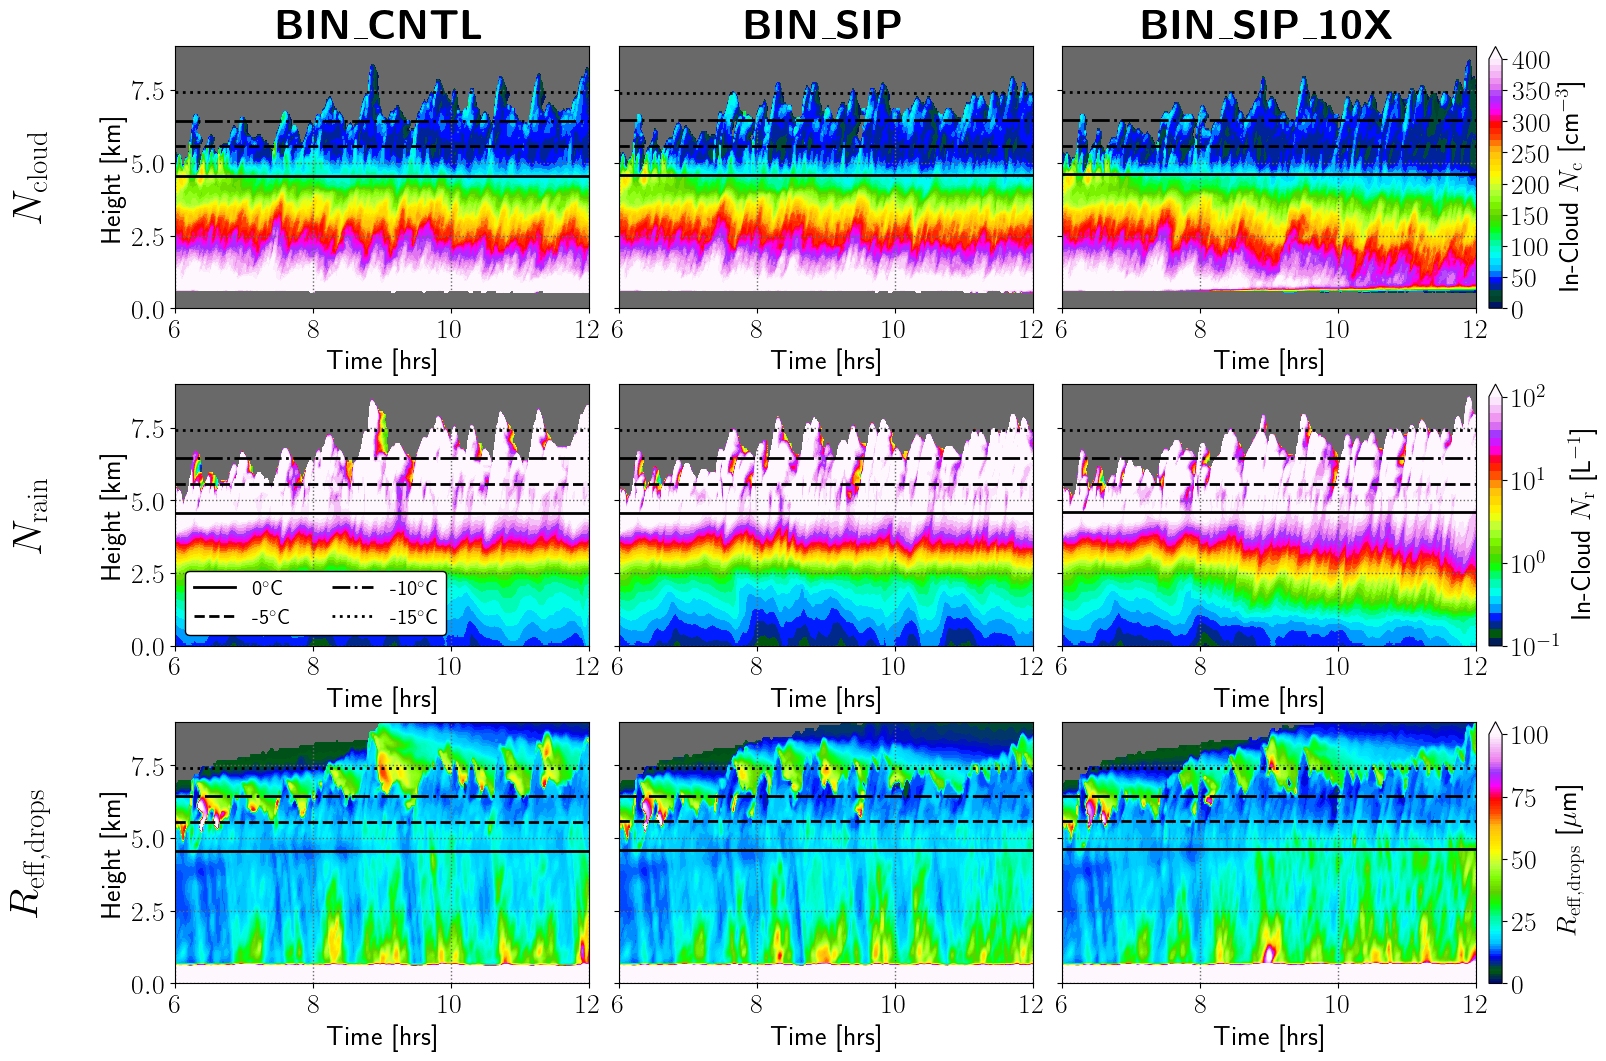

In [50]:

# ---------------------------------------------------------------------------
# BIN turb (top) vs BIN noturb (bottom) — same layout as the BIN/BULK figure
# ---------------------------------------------------------------------------
bin_dicts  = [bin_cntl_d,       bin_sip_d,        bin_sip10_d]
row_labels = [r'\textbf{N_${c}$}', r'\textbf{N_${r}$}',r'\textbf{N_${tot}$}',]

#cmap = 'nipy_spectral'

cmap_name = 'gist_ncar'
# Get a copy of the colormap
cmap = plt.get_cmap(cmap_name).copy()
# Tell it to color bad values (NaNs) with a light grey
cmap.set_bad(color='dimgrey')
#cmap.set_under(color='dimgrey')

Fontsize=20


# ---------------------------------------------------------------------------
# Unpack time and grids (bin: time in s -> hours; bulk: tmp_time already hours)
# ---------------------------------------------------------------------------
def bin_time(d):     return d['time'] / 3600.
def get_zt(d):       return np.asarray(d['zt'])  * 1.e-3   # m -> km
def get_var(d, key): return d[key].copy() # cm-3
def get_T(d):        return d['T']# K
fig, axes = plt.subplots(3, 3, figsize=(16, 10.5), constrained_layout=True)

#==================================
# nqc
#==================================
bin_levels   = np.arange(0,410,10)
#bin_norm     = matplotlib.colors.LogNorm(vmin=1, vmax=1.e3)
bin_norm     = None
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
#bin_cb_ticks = 10.**np.arange(0, 4, 1)
bin_cb_ticks = np.arange(0,450,50)


#bin_var_key  = 'nqc'   
bin_var_key  = 'nc_cld'   
pm_bin   = []
for col, d in enumerate(bin_dicts):
    t  = bin_time(d)
    zt = get_zt(d)
    Nc = get_var(d, bin_var_key)
    Nc[Nc < 1] = np.nan
    pm_bin.append(  axes[0, col].contourf(t, zt, Nc.T, **bin_kw))

cb   = fig.colorbar(pm_bin[0],   ax=axes[0, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
cb.ax.tick_params(labelsize=Fontsize)
bin_label = r'In-Cloud $N_{\mathrm{c}}$ [cm$^{-3}$]'
cb.set_label(bin_label, fontsize=Fontsize)
#==================================
# nqr
#==================================
bin_levels   = 10.**np.arange(-1,2.1,0.1)
bin_norm     = matplotlib.colors.LogNorm(vmin=1.e-1, vmax=1.e2)
#bin_norm     = None
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
bin_cb_ticks = 10.**np.arange(-1,3,1)
#bin_cb_ticks = np.arange(0,800,100)


#bin_var_key  = 'nqr'   
bin_var_key  = 'nr_cld'   
pm_bin   = []
for col, d in enumerate(bin_dicts):
    t  = bin_time(d)
    zt = get_zt(d)
    Nr = get_var(d, bin_var_key)
    Nr[np.log10(Nr*1.e3) < -1.] = np.nan
    pm_bin.append(  axes[1, col].contourf(t, zt, Nr.T*1.e3, **bin_kw))

cb   = fig.colorbar(pm_bin[0],   ax=axes[1, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
cb.ax.tick_params(labelsize=Fontsize)
bin_label = r'In-Cloud $N_{\mathrm{r}}$ [L$^{-1}$]'
cb.set_label(bin_label, fontsize=Fontsize)

if False:
    #==================================
    # nql
    #==================================
    bin_levels   = np.arange(0,410,10)
    #bin_norm     = matplotlib.colors.LogNorm(vmin=1, vmax=1.e3)
    bin_norm     = None
    bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
    #bin_cb_ticks = 10.**np.arange(0, 4, 1)
    bin_cb_ticks = np.arange(0,450,50)
    
    
    bin_var_key  = 'nql'   
    pm_bin   = []
    for col, d in enumerate(bin_dicts):
        t  = bin_time(d)
        zt = get_zt(d)
        Nl = get_var(d, bin_var_key)
        print(np.max(Nl))
        pm_bin.append(  axes[2, col].contourf(t, zt, Nl.T, **bin_kw))
    cb   = fig.colorbar(pm_bin[0],   ax=axes[2, :].tolist(),
                               location='right', pad=0.0, ticks=bin_cb_ticks)
    cb.ax.tick_params(labelsize=Fontsize)
    bin_label = r'Mass-weighted $N_{\mathrm{tot}}$ [L$^{-1}$]'
    cb.set_label(bin_label, fontsize=Fontsize)

if True:
    #==================================
    # Reff_drops
    #==================================
    bin_levels   = np.arange(0,101,1)
    #bin_norm     = matplotlib.colors.LogNorm(vmin=1, vmax=1.e3)
    bin_norm     = None
    bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
    #bin_cb_ticks = 10.**np.arange(0, 4, 1)
    bin_cb_ticks = np.arange(0,125,25)
    
    
    bin_var_key  = 'reff_drops'   
    pm_bin   = []
    for col, d in enumerate(bin_dicts):
        t  = bin_time(d)
        zt = get_zt(d)
        var = get_var(d, bin_var_key)
        var[var < 1] = np.nan
        pm_bin.append(  axes[2, col].contourf(t, zt, var.T, **bin_kw))
    
    cb   = fig.colorbar(pm_bin[0],   ax=axes[2, :].tolist(),
                               location='right', pad=0.0, ticks=bin_cb_ticks)
    cb.ax.tick_params(labelsize=Fontsize)
    bin_label = r'$R_{\mathrm{eff,drops}}$ [$\mu$m]'
    cb.set_label(bin_label, fontsize=Fontsize)

for row in np.arange(3):
    for col in np.arange(3):
        ax = axes[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        ax.set_xlim(6, 12)
        ax.set_ylim(0,9)
        ax.set_facecolor('dimgrey')



# Mean-T isotherms
tmp_color = 'k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'


for row in np.arange(3):
    for col in np.arange(3):
        ax   = axes[row, col]
        if col == 0.:
            d = bin_cntl_d
        elif col == 1.:
            d= bin_sip_d
        else:
            d = bin_sip10_d
        zt_d = get_zt(d);   T_d = get_T(d);   t_d = bin_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)
            
legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd = axes[1, 0].legend(legend_lines, legend_labels, loc='lower left',
                             bbox_to_anchor=(0., 0.), fontsize=Fontsize*0.75, ncol=2,
                             framealpha=True, edgecolor='k')

texts = [r'$N_{\mathrm{cloud}}$',r'$N_{\mathrm{rain}}$',r'$R_{\mathrm{eff,drops}}$']
for row in np.arange(3):
    ax = axes[row,0]
    ax.text(-0.35,0.5,texts[row],fontsize=Fontsize*1.5,va='center',ha='center',rotation=90,transform=ax.transAxes)

labels = [r'\textbf{BIN_CNTL}',r'\textbf{BIN_SIP}',r'\textbf{BIN_SIP_10X}']
for col in np.arange(3):
    ax = axes[0,col]
    ax.set_title(labels[col],fontsize=Fontsize*1.5)

plt.show()


In [41]:
np.nanmin(np.log10(Nr*1.e3))

2.0000815

In [ ]:
for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax = axes2[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        ax.set_xlim(6, 12)
        ax.set_ylim(3, 9)
        ax.text(0.02, 0.98, panel_ids[row * 3 + col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)

    axes2[row, 0].text(-0.15, 0.5, row_labels_noturb[row], fontsize=Fontsize * 1.5,
                       fontweight='bold', c='k', transform=axes2[row, 0].transAxes,
                       va='center', ha='center', rotation=90)

for col, title in enumerate(col_titles):
    axes2[0, col].set_title(title, fontsize=Fontsize * 1.5)

# Mean-T isotherms
for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax   = axes2[row, col]
        zt_d = get_zt(d);   T_d = get_T(d);   t_d = bin_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)

lgnd2 = axes2[1, 0].legend(legend_lines, legend_labels, loc='lower left',
                             bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=2,
                             framealpha=True, edgecolor='k')

/tmp/ipykernel_324595/164916072.py:69: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bin.append( axes[0, col].contourf(t_b, zt_b, Ni_b.T,  **bin_kw))
/tmp/ipykernel_324595/164916072.py:70: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bulk.append(axes[1, col].contourf(t_k, zt_k, Ni_k.T,  **bulk_kw))


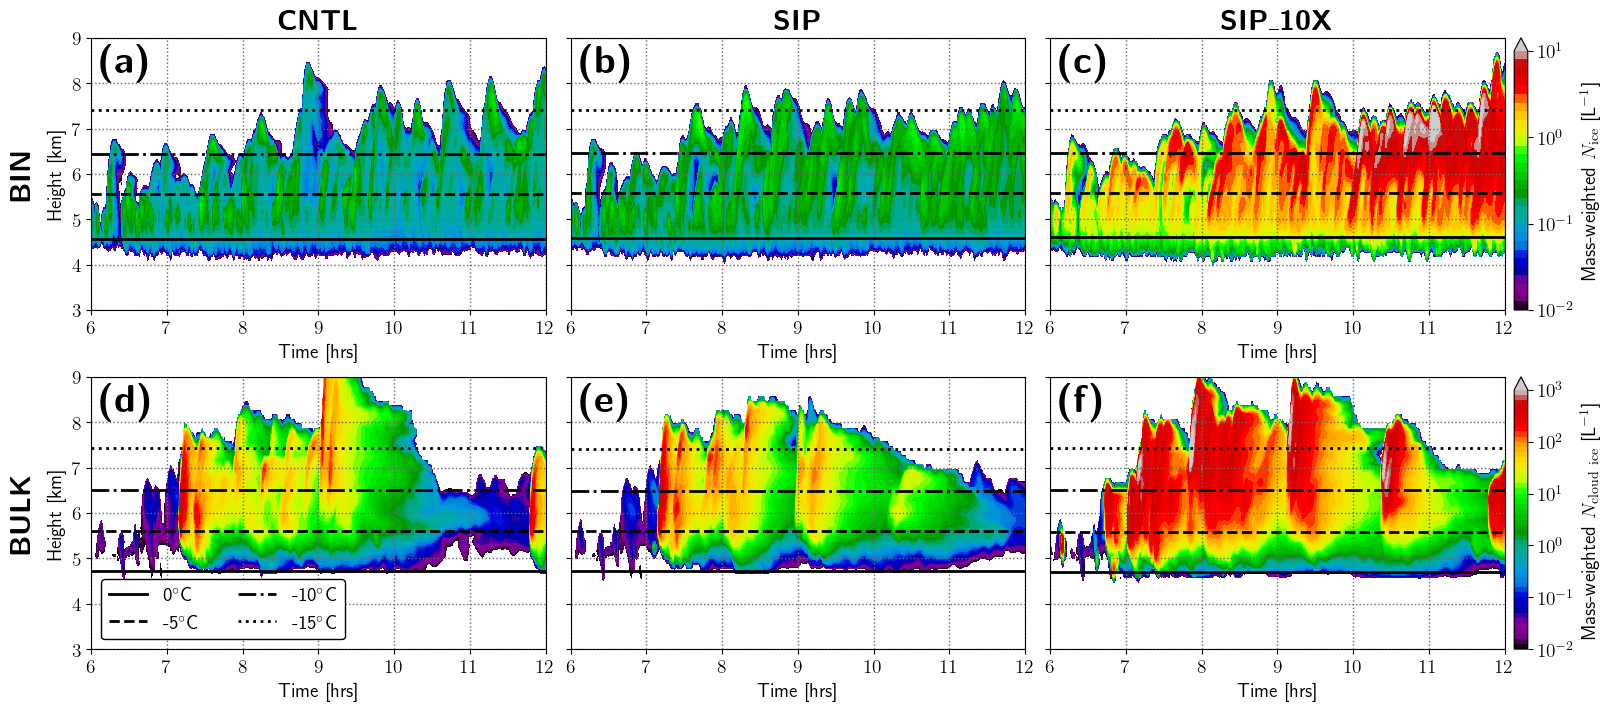

In [114]:
Fontsize    = 14
panel_props = dict(boxstyle='square', facecolor='white', alpha=0.85,
                   edgecolor='k', linewidth=0.8, pad=0.2)
panel_ids   = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}',
               r'\textbf{(d)}', r'\textbf{(e)}', r'\textbf{(f)}']
col_titles  = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']
row_labels  = [r'\textbf{BIN}', r'\textbf{BULK}']

# ---------------------------------------------------------------------------
# Choose variable: 'nif_cld' or 'nqif' for bin; 'nic_cld' or 'nqic' for bulk
# (multiply by 1e3 to convert cm-3 -> L-1)
# ---------------------------------------------------------------------------
#bin_var_key  = 'nif_cld'   # swap to 'nqif'  if desired
#bulk_var_key = 'nic_cld'   # swap to 'nqic'  if desired
bin_var_key  = 'nqif'   # swap to 'nqif'  if desired
bulk_var_key = 'nqic'   # swap to 'nqic'  if desired
bin_label    = r'Mass-weighted $N_{\mathrm{ice}}$ [L$^{-1}$]'
bulk_label   = r'Mass-weighted $N_{\mathrm{cloud \ ice}}$ [L$^{-1}$]'

# ---------------------------------------------------------------------------
# Unpack time and grids (bin: time in s -> hours; bulk: tmp_time already hours)
# ---------------------------------------------------------------------------
def bin_time(d):     return d['time'] / 3600.
def bulk_time(d):    return d['tmp_time']
def get_zt(d):       return np.asarray(d['zt'])  * 1.e-3   # m -> km
def get_var(d, key): return d[key] * 1.e3                   # cm-3 -> L-1
def get_T(d):        return d['T']                          # K

# ---------------------------------------------------------------------------
# Colormap & levels (shared within each row; independent between rows)
# ---------------------------------------------------------------------------
#cmap = 'magma'
#cmap = 'turbo'
cmap = 'nipy_spectral'

bin_levels   = 10.**np.arange(-2, 1.1, 0.1)
bin_norm     = matplotlib.colors.LogNorm(vmin=1.e-2, vmax=10.)
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
bin_cb_ticks = 10.**np.arange(-2, 2, 1)

bulk_levels   = 10.**np.arange(-2, 3.1, 0.1)
bulk_norm     = matplotlib.colors.LogNorm(vmin=1.e-2, vmax=1.e3)
bulk_kw       = dict(cmap=cmap, levels=bulk_levels, norm=bulk_norm, extend='max')
bulk_cb_ticks = 10.**np.arange(-2, 4, 1)

# ---------------------------------------------------------------------------
# Build data lists  [cntl, sip, sip_10x]
# ---------------------------------------------------------------------------
bin_dicts  = [bin_cntl_d,  bin_sip_d,  bin_sip10_d]
bulk_dicts = [bulk_cntl_d, bulk_sip_d, bulk_sip10_d]

# ---------------------------------------------------------------------------
# Figure  — extra width on the right for the two vertical colorbars
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

# Contourf: top row = bin, bottom row = bulk
pm_bin  = []
pm_bulk = []
for col, (bd, kd) in enumerate(zip(bin_dicts, bulk_dicts)):
    t_b  = bin_time(bd)
    zt_b = get_zt(bd)
    Ni_b = get_var(bd, bin_var_key)

    t_k  = bulk_time(kd)
    zt_k = get_zt(kd)
    Ni_k = get_var(kd, bulk_var_key)

    pm_bin.append( axes[0, col].contourf(t_b, zt_b, Ni_b.T,  **bin_kw))
    pm_bulk.append(axes[1, col].contourf(t_k, zt_k, Ni_k.T,  **bulk_kw))

# Vertical colorbars on the right side of each row
cb_bin  = fig.colorbar(pm_bin[0],  ax=axes[0, :].tolist(),
                        location='right', pad=0.0, ticks=bin_cb_ticks)
cb_bulk = fig.colorbar(pm_bulk[0], ax=axes[1, :].tolist(),
                        location='right', pad=0.0, ticks=bulk_cb_ticks)
cb_bin.ax.tick_params(labelsize=Fontsize)
cb_bin.set_label(bin_label, fontsize=Fontsize)
cb_bulk.ax.tick_params(labelsize=Fontsize)
cb_bulk.set_label(bulk_label, fontsize=Fontsize)

# ---------------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------------
for row, dicts in enumerate([bin_dicts, bulk_dicts]):
    for col, d in enumerate(dicts):
        ax = axes[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.set_ylim(0, 8)
        ax.grid(ls='dotted', lw=1, c='dimgrey')

        # x-axis labels only on bottom row
        #if row == 1:
        #    ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        #else:
        #    ax.tick_params(axis='x', labelbottom=False)
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)

        # y-axis labels/ticklabels only on left column
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')

        # xlim from data
        t = bin_time(d) if row == 0 else bulk_time(d)
        ax.set_xlim(t[0], t[-1])

        # Panel label
        ax.text(0.02, 0.98, panel_ids[row * 3 + col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)
                #va='center', ha='center', bbox=panel_props, zorder=5)

    # Row label on the left outside the first column
    axes[row, 0].text(-0.15, 0.5, row_labels[row], fontsize=Fontsize * 1.5,
                      fontweight='bold', c='k', transform=axes[row, 0].transAxes,
                      va='center', ha='center', rotation=90)

# Column titles on top row only
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=Fontsize * 1.5)

# ---------------------------------------------------------------------------
# Mean-T isotherms (last 6 hours of each simulation)
# ---------------------------------------------------------------------------
tmp_color = 'k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'

for row, dicts in enumerate([bin_dicts, bulk_dicts]):
    for col, d in enumerate(dicts):
        ax    = axes[row, col]
        zt_d  = get_zt(d)
        T_d   = get_T(d)
        t_d   = bin_time(d) if row == 0 else bulk_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)

# Temperature legend on top-left panel
legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd = axes[1, 0].legend(legend_lines, legend_labels, loc='lower left',
                          bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=2,
                          framealpha=True, edgecolor='k')

for ax in axes[0,:]:
    ax.set_xlim(6,12)
    ax.set_ylim(3,9)

for ax in axes[1,:]:
    ax.set_xlim(6,12)
    ax.set_ylim(3,9)

plt.show()

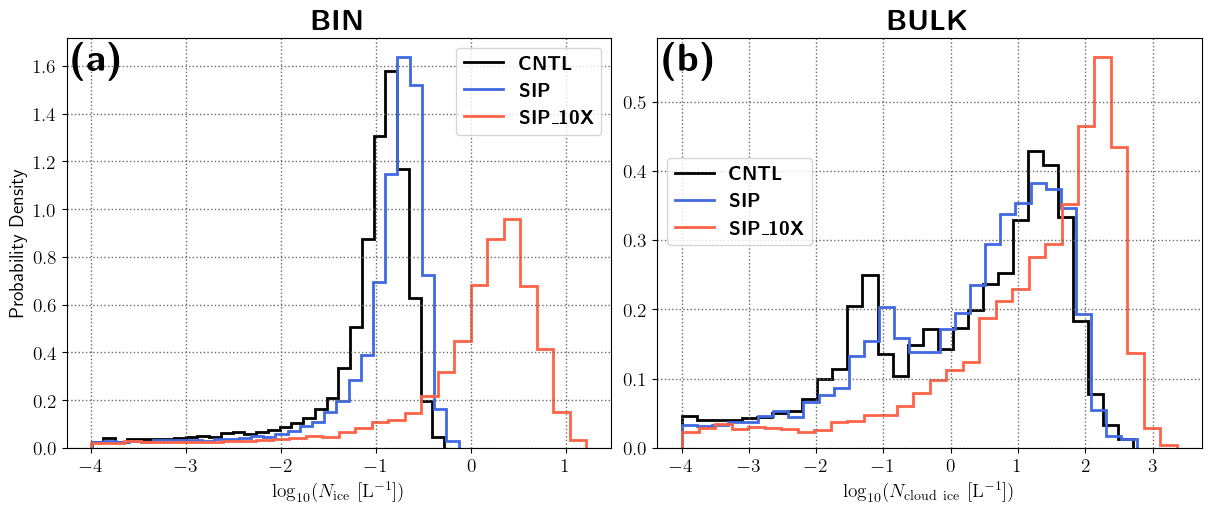

In [115]:
bin_dicts  = [bin_cntl_d,  bin_sip_d,  bin_sip10_d]
bulk_dicts = [bulk_cntl_d, bulk_sip_d, bulk_sip10_d]

# ============================================================
# PDFs of nqif (BIN) and nqic (BULK)  [units: /cm3 -> /L]
# Exclude samples < 1e-2 L-1; log10 transform; linear binning
# Use np.histogram + plt.stairs so lw and ls both work
# ============================================================
sim_colors = ['k', 'royalblue', 'tomato']
sim_lws    = [2, 2, 2]
sim_ls     = ['solid', 'solid', 'solid']
sim_names  = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']
threshold  = 1.e-4   # L-1
nbins      = 30
Fontsize=14

fig_pdf, (ax_bin, ax_bulk) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# BIN: nqif  (/cm3 -> /L  *1e3)
for d, color, lw, ls, name in zip(bin_dicts, sim_colors, sim_lws, sim_ls, sim_names):
    samples = d['nqif'].ravel() * 1.e3   # -> L-1
    samples = samples[samples >= threshold]
    counts, edges = np.histogram(np.log10(samples), bins=nbins, density=True)
    ax_bin.stairs(counts, edges, color=color, lw=lw, linestyle=ls, label=name)

ax_bin.set_xlabel(r'$\log_{10}(N_{\mathrm{ice}}\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
ax_bin.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin.tick_params(labelsize=Fontsize)
ax_bin.legend(fontsize=Fontsize)
ax_bin.grid(ls='dotted', lw=1, c='dimgrey')
ax_bin.set_title(r'\textbf{BIN}', fontsize=Fontsize * 1.5)


sim_colors = ['k', 'royalblue', 'tomato']
sim_lws    = [2, 2, 2]
sim_ls     = ['solid', 'solid', 'solid', ]
sim_names  = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']
threshold  = 1.e-4   # L-1
nbins      = 30

# BULK: nqic  (/cm3 -> /L  *1e3)
for d, color, lw, ls, name in zip(bulk_dicts, sim_colors, sim_lws, sim_ls, sim_names):
    samples = d['nqic'].ravel() * 1.e3   # -> L-1
    samples = samples[samples >= threshold]
    counts, edges = np.histogram(np.log10(samples), bins=nbins, density=True)
    ax_bulk.stairs(counts, edges, color=color, lw=lw, linestyle=ls, label=name)

ax_bulk.set_xlabel(r'$\log_{10}(N_{\mathrm{cloud \ ice}}\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
#ax_bulk.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bulk.tick_params(labelsize=Fontsize)
ax_bulk.legend(fontsize=Fontsize,loc='center left', bbox_to_anchor=(0., 0.6))
ax_bulk.grid(ls='dotted', lw=1, c='dimgrey')
ax_bulk.set_title(r'\textbf{BULK}', fontsize=Fontsize * 1.5)

ax_bin.text(0.01,0.99,r'\textbf{(a)}',fontsize=Fontsize*2,transform=ax_bin.transAxes,ha='left',va='top')
ax_bulk.text(0.01,0.99,r'\textbf{(b)}',fontsize=Fontsize*2,transform=ax_bulk.transAxes,ha='left',va='top')

plt.show()

/tmp/ipykernel_324595/372174182.py:21: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bin_turb.append(  axes2[0, col].contourf(t_t, zt_t, Ni_t.T, **bin_kw))
/tmp/ipykernel_324595/372174182.py:22: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bin_noturb.append(axes2[1, col].contourf(t_n, zt_n, Ni_n.T, **bin_kw))


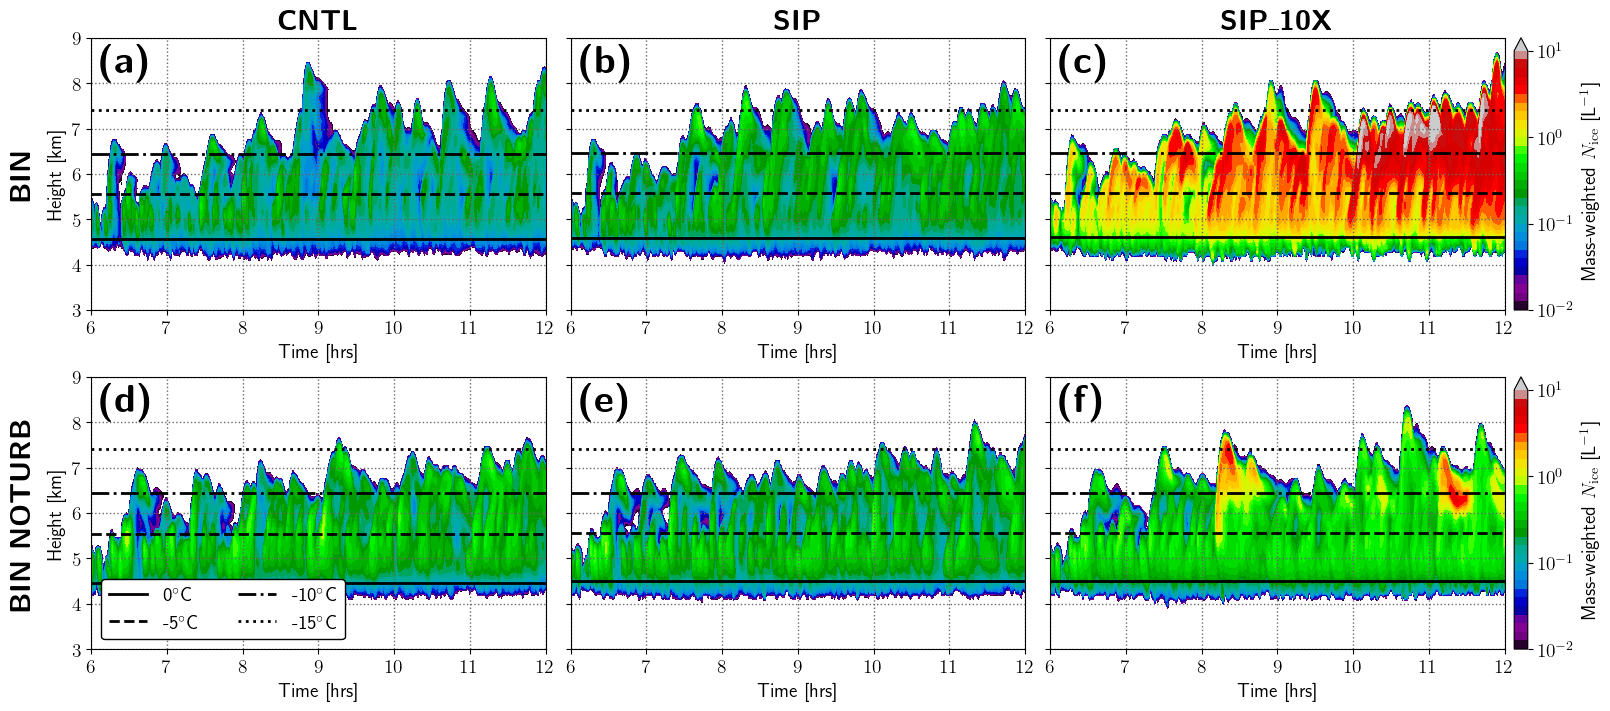

In [116]:

# ---------------------------------------------------------------------------
# BIN turb (top) vs BIN noturb (bottom) — same layout as the BIN/BULK figure
# ---------------------------------------------------------------------------
turb_bin_dicts  = [bin_cntl_d,       bin_sip_d,        bin_sip10_d]
noturb_bin_dicts = [bin_cntl_noturb_d, bin_sip_noturb_d, bin_sip10_noturb_d]
row_labels_noturb = [r'\textbf{BIN}', r'\textbf{BIN NOTURB}']

bin_levels   = 10.**np.arange(-2, 1.1, 0.1)
bin_norm     = matplotlib.colors.LogNorm(vmin=1.e-2, vmax=1.e1)
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
bin_cb_ticks = 10.**np.arange(-2, 2, 1)


fig2, axes2 = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

pm_bin_turb   = []
pm_bin_noturb = []
for col, (td, nd) in enumerate(zip(turb_bin_dicts, noturb_bin_dicts)):
    t_t  = bin_time(td);   zt_t = get_zt(td);   Ni_t = get_var(td, bin_var_key)
    t_n  = bin_time(nd);   zt_n = get_zt(nd);   Ni_n = get_var(nd, bin_var_key)
    pm_bin_turb.append(  axes2[0, col].contourf(t_t, zt_t, Ni_t.T, **bin_kw))
    pm_bin_noturb.append(axes2[1, col].contourf(t_n, zt_n, Ni_n.T, **bin_kw))

cb_turb   = fig2.colorbar(pm_bin_turb[0],   ax=axes2[0, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
cb_noturb = fig2.colorbar(pm_bin_noturb[0], ax=axes2[1, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
for cb in [cb_turb, cb_noturb]:
    cb.ax.tick_params(labelsize=Fontsize)
    cb.set_label(bin_label, fontsize=Fontsize)

for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax = axes2[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        ax.set_xlim(6, 12)
        ax.set_ylim(3, 9)
        ax.text(0.02, 0.98, panel_ids[row * 3 + col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)

    axes2[row, 0].text(-0.15, 0.5, row_labels_noturb[row], fontsize=Fontsize * 1.5,
                       fontweight='bold', c='k', transform=axes2[row, 0].transAxes,
                       va='center', ha='center', rotation=90)

for col, title in enumerate(col_titles):
    axes2[0, col].set_title(title, fontsize=Fontsize * 1.5)

# Mean-T isotherms
for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax   = axes2[row, col]
        zt_d = get_zt(d);   T_d = get_T(d);   t_d = bin_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)

lgnd2 = axes2[1, 0].legend(legend_lines, legend_labels, loc='lower left',
                             bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=2,
                             framealpha=True, edgecolor='k')

plt.show()


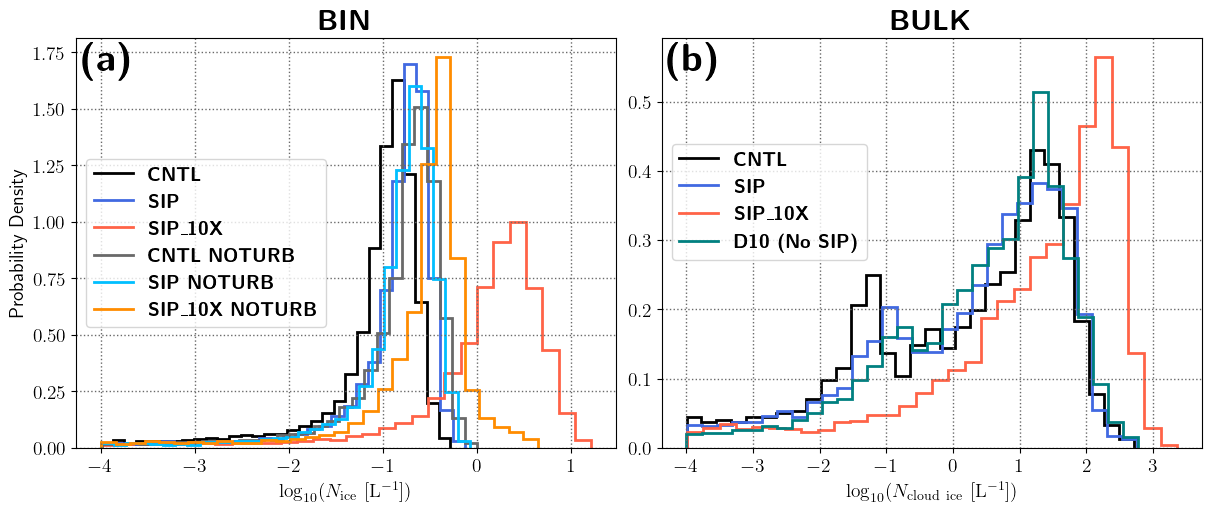

In [117]:
bin_dicts  = [bin_cntl_d,  bin_sip_d,  bin_sip10_d, bin_cntl_noturb_d, bin_sip_noturb_d, bin_sip10_noturb_d]
#bulk_dicts = [bulk_cntl_d, bulk_cntl_d10_d, bulk_sip_d, bulk_sip10_d]
bulk_dicts = [bulk_cntl_d, bulk_sip_d, bulk_sip10_d, bulk_cntl_d10_d]
#

# ============================================================
# PDFs of nqif (BIN) and nqic (BULK)  [units: /cm3 -> /L]
# Exclude samples < 1e-2 L-1; log10 transform; linear binning
# Use np.histogram + plt.stairs so lw and ls both work
# Only sample t >= 6 hrs to exclude spin-up
# ============================================================
sim_colors = ['k', 'royalblue', 'tomato','dimgrey','deepskyblue','darkorange']
sim_lws    = [2, 2, 2, 2, 2, 2]
sim_ls     = ['solid', 'solid', 'solid', 'solid','solid','solid']
sim_names  = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}',\
              r'\textbf{CNTL NOTURB}', r'\textbf{SIP NOTURB}', r'\textbf{SIP\_10X NOTURB}',\
              ]
threshold  = 1.e-4   # L-1
nbins      = 30
Fontsize=14

fig_pdf, (ax_bin, ax_bulk) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# BIN: nqif  (/cm3 -> /L  *1e3)
for d, color, lw, ls, name in zip(bin_dicts, sim_colors, sim_lws, sim_ls, sim_names):
    t_mask = d['time'] / 3600. >= 6.
    samples = d['nqif'][t_mask, :].ravel() * 1.e3   # -> L-1
    samples = samples[samples >= threshold]
    counts, edges = np.histogram(np.log10(samples), bins=nbins, density=True)
    ax_bin.stairs(counts, edges, color=color, lw=lw, linestyle=ls, label=name)

ax_bin.set_xlabel(r'$\log_{10}(N_{\mathrm{ice}}\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
ax_bin.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin.tick_params(labelsize=Fontsize)
ax_bin.legend(fontsize=Fontsize)
ax_bin.grid(ls='dotted', lw=1, c='dimgrey')
ax_bin.set_title(r'\textbf{BIN}', fontsize=Fontsize * 1.5)


sim_colors = ['k', 'royalblue', 'tomato','teal']
sim_lws    = [2, 2, 2, 2]
sim_ls     = ['solid', 'solid', 'solid', 'solid']
sim_names  = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}', r'\textbf{D10 (No SIP)}']
threshold  = 1.e-4   # L-1
nbins      = 30

# BULK: nqic  (/cm3 -> /L  *1e3)
for d, color, lw, ls, name in zip(bulk_dicts, sim_colors, sim_lws, sim_ls, sim_names):
    t_mask = d['tmp_time'] >= 6.
    samples = d['nqic'][t_mask, :].ravel() * 1.e3   # -> L-1
    samples = samples[samples >= threshold]
    counts, edges = np.histogram(np.log10(samples), bins=nbins, density=True)
    ax_bulk.stairs(counts, edges, color=color, lw=lw, linestyle=ls, label=name)

ax_bulk.set_xlabel(r'$\log_{10}(N_{\mathrm{cloud \ ice}}\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
#ax_bulk.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bulk.tick_params(labelsize=Fontsize)
ax_bulk.legend(fontsize=Fontsize,loc='center left', bbox_to_anchor=(0., 0.6))
ax_bulk.grid(ls='dotted', lw=1, c='dimgrey')
ax_bulk.set_title(r'\textbf{BULK}', fontsize=Fontsize * 1.5)

ax_bin.text(0.01,0.99,r'\textbf{(a)}',fontsize=Fontsize*2,transform=ax_bin.transAxes,ha='left',va='top')
ax_bulk.text(0.01,0.99,r'\textbf{(b)}',fontsize=Fontsize*2,transform=ax_bulk.transAxes,ha='left',va='top')

plt.show()


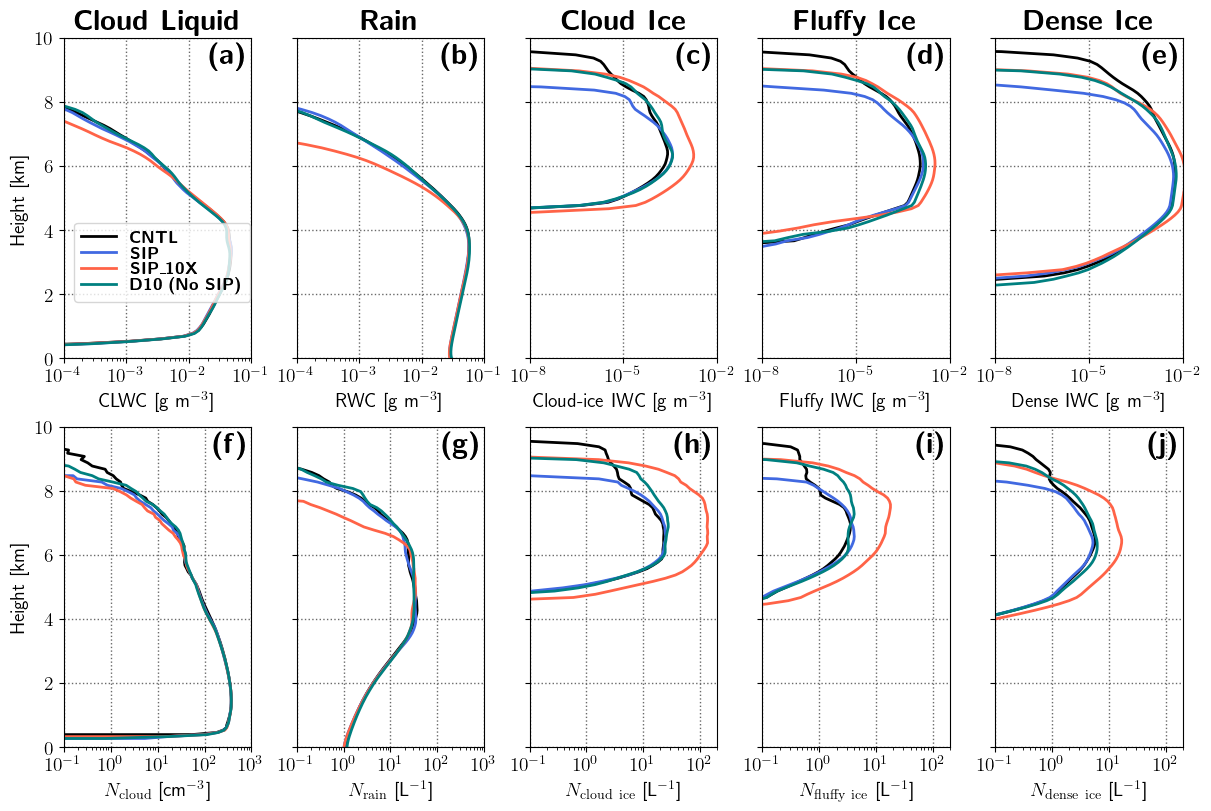

In [58]:
# ============================================================
# BULK mean profiles averaged over hours 9 – 12
# Top row : mass  — clwc, rwc, qic_iwc, qif_iwc, qid_iwc
# Bottom row: number — nc_cld, nr_cld, nqic, nqif, nqid
# CNTL=black, SIP=royalblue, SIP_10X=tomato
# ============================================================
mass_vars   = ['clwc','rwc','qic_iwc','qif_iwc','qid_iwc']
mass_labels = [r'CLWC [g m$^{-3}$]',
               r'RWC [g m$^{-3}$]',
               r'Cloud-ice IWC [g m$^{-3}$]',
               r'Fluffy IWC [g m$^{-3}$]',
               r'Dense IWC [g m$^{-3}$]']

num_vars    = ['nqc',  'nqr',  'nqic',   'nqif',   'nqid']
num_labels  = [r'$N_{\mathrm{cloud}}$ [cm$^{-3}$]',
               r'$N_{\mathrm{rain}}$ [L$^{-1}$]',
               r'$N_{\mathrm{cloud \ ice}}$ [L$^{-1}$]',
               r'$N_{\mathrm{fluffy \ ice}}$ [L$^{-1}$]',
               r'$N_{\mathrm{dense \ ice}}$ [L$^{-1}$]']

fig_prof, axes_prof = plt.subplots(2, 5, figsize=(12, 8), constrained_layout=True)

for col, (mass_var, mass_lbl, num_var, num_lbl) in enumerate(
        zip(mass_vars, mass_labels, num_vars, num_labels)):
    ax_top = axes_prof[0, col]
    ax_bot = axes_prof[1, col]

    # nqc (cloud) stays in cm-3; all others convert cm-3 -> L-1 (*1e3)
    num_scale = 1.0 if col == 0 else 1.e3

    for d, color, lw, ls, name in zip(bulk_dicts, sim_colors, sim_lws, sim_ls, sim_names):
        t    = d['tmp_time']                      # hours
        mask = (t >= 6.) & (t <= 12.)
        zt   = np.asarray(d['zt']) * 1.e-3        # m -> km

        mean_mass = np.mean(d[mass_var][mask, :], axis=0)
        mean_num  = np.mean(d[num_var][mask,  :], axis=0) * num_scale

        ax_top.plot(mean_mass, zt, color=color, lw=lw, linestyle=ls, label=name)
        ax_bot.plot(mean_num,  zt, color=color, lw=lw, linestyle=ls)

    for ax, lbl in [(ax_top, mass_lbl), (ax_bot, num_lbl)]:
        ax.set_ylim(0, 10)
        ax.set_xlabel(lbl, fontsize=Fontsize)
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.set_xscale('log')

    # y-axis labels only on left column
    if col == 0:
        ax_top.set_ylabel('Height [km]', fontsize=Fontsize)
        ax_bot.set_ylabel('Height [km]', fontsize=Fontsize)
    else:
        ax_top.tick_params(axis='y', labelleft=False)
        ax_bot.tick_params(axis='y', labelleft=False)

    # suppress x tick labels on top row
    #ax_top.tick_params(axis='x', labelbottom=False)

# Legend on top-left panel
axes_prof[0, 0].legend(fontsize=Fontsize*0.9, loc='center left',labelspacing=0.01,bbox_to_anchor=(0.01,0.3))
#plt.suptitle(r'\textbf{BULK: Mean Profiles (9--12 hrs)}',
#             fontsize=Fontsize * 1.5, fontweight='bold')

axes_prof[0,0].set_xlim(1.e-4,1.e-1)
axes_prof[0,1].set_xlim(1.e-4,1.e-1)
axes_prof[0,2].set_xlim(1.e-8,1.e-2)
axes_prof[0,3].set_xlim(1.e-8,1.e-2)
axes_prof[0,4].set_xlim(1.e-8,1.e-2)

axes_prof[1,0].set_xlim(1.e-1,1.e3)
axes_prof[1,1].set_xlim(1.e-1,1.e3)
axes_prof[1,2].set_xlim(1.e-1,200)
axes_prof[1,3].set_xlim(1.e-1,200)
axes_prof[1,4].set_xlim(1.e-1,200)

# Panel labels (a)-(j), top-left of each panel, no background box
prof_panel_ids = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}', r'\textbf{(d)}', r'\textbf{(e)}',
                  r'\textbf{(f)}', r'\textbf{(g)}', r'\textbf{(h)}', r'\textbf{(i)}', r'\textbf{(j)}']
for idx, ax in enumerate(axes_prof.ravel()):
    ax.text(0.99, 0.99, prof_panel_ids[idx], fontsize=Fontsize*1.5,
            fontweight='bold', c='k', transform=ax.transAxes,
            va='top', ha='right')

axes_prof[0,0].set_title(r'\textbf{Cloud Liquid}', fontsize=Fontsize * 1.5)
axes_prof[0,1].set_title(r'\textbf{Rain}', fontsize=Fontsize * 1.5)
axes_prof[0,2].set_title(r'\textbf{Cloud Ice}', fontsize=Fontsize * 1.5)
axes_prof[0,3].set_title(r'\textbf{Fluffy Ice}', fontsize=Fontsize * 1.5)
axes_prof[0,4].set_title(r'\textbf{Dense Ice}', fontsize=Fontsize * 1.5)

plt.show()

/tmp/ipykernel_324595/4008892256.py:55: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bulk.append(axes[col].contourf(t_k, zt_k, Ni_k.T,  **bulk_kw))


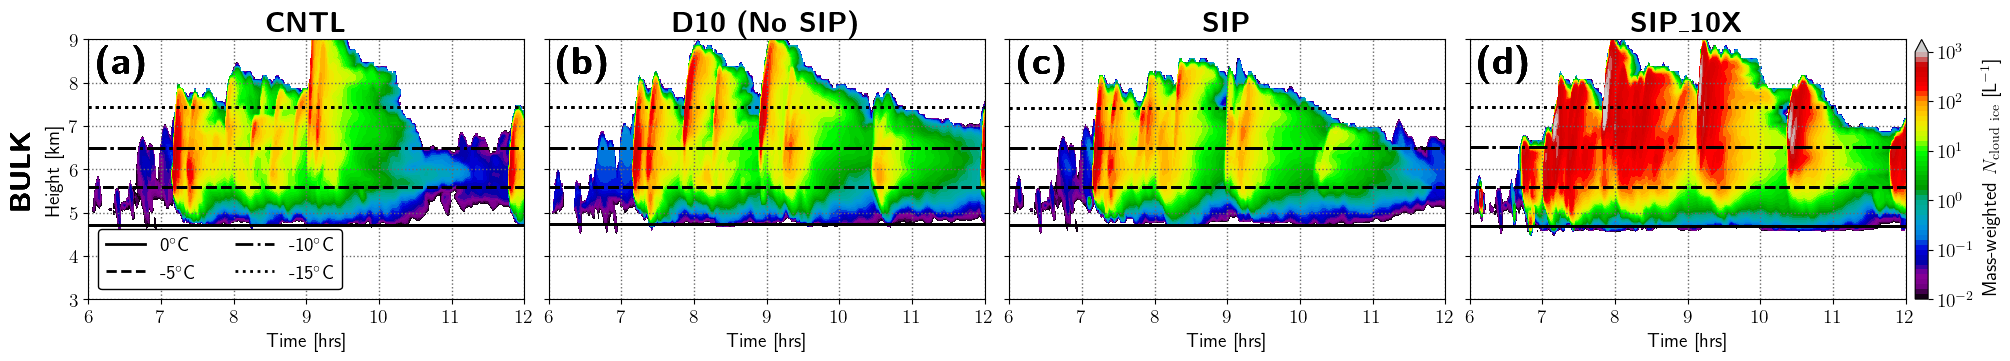

In [59]:
Fontsize    = 14
panel_props = dict(boxstyle='square', facecolor='white', alpha=0.85,
                   edgecolor='k', linewidth=0.8, pad=0.2)
panel_ids   = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}',
               r'\textbf{(d)}', r'\textbf{(e)}', r'\textbf{(f)}']
col_titles  = [r'\textbf{CNTL}', r'\textbf{D10 (No SIP)}', r'\textbf{SIP}', r'\textbf{SIP\_10X}']

# ---------------------------------------------------------------------------
# Choose variable: 'nif_cld' or 'nqif' for bin; 'nic_cld' or 'nqic' for bulk
# (multiply by 1e3 to convert cm-3 -> L-1)
# ---------------------------------------------------------------------------
#bulk_var_key = 'nic_cld'   # swap to 'nqic'  if desired
bulk_var_key = 'nqic'   # swap to 'nqic'  if desired
bulk_label   = r'Mass-weighted $N_{\mathrm{cloud \ ice}}$ [L$^{-1}$]'

# ---------------------------------------------------------------------------
# Unpack time and grids (bin: time in s -> hours; bulk: tmp_time already hours)
# ---------------------------------------------------------------------------
def bulk_time(d):    return d['tmp_time']
def get_zt(d):       return np.asarray(d['zt'])  * 1.e-3   # m -> km
def get_var(d, key): return d[key] * 1.e3                   # cm-3 -> L-1
def get_T(d):        return d['T']                          # K

# ---------------------------------------------------------------------------
# Colormap & levels (shared within each row; independent between rows)
# ---------------------------------------------------------------------------
#cmap = 'magma'
#cmap = 'turbo'
cmap = 'nipy_spectral'


bulk_levels   = 10.**np.arange(-2, 3.1, 0.1)
bulk_norm     = matplotlib.colors.LogNorm(vmin=1.e-2, vmax=1.e3)
bulk_kw       = dict(cmap=cmap, levels=bulk_levels, norm=bulk_norm, extend='max')
bulk_cb_ticks = 10.**np.arange(-2, 4, 1)

# ---------------------------------------------------------------------------
# Build data lists  [cntl, sip, sip_10x]
# ---------------------------------------------------------------------------
bulk_dicts = [bulk_cntl_d, bulk_cntl_d10_d,bulk_sip_d, bulk_sip10_d]

# ---------------------------------------------------------------------------
# Figure  — extra width on the right for the two vertical colorbars
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5), constrained_layout=True)

# Contourf: top row = bin, bottom row = bulk
pm_bulk = []
for col, kd in enumerate(bulk_dicts):

    t_k  = bulk_time(kd)
    zt_k = get_zt(kd)
    Ni_k = get_var(kd, bulk_var_key)

    pm_bulk.append(axes[col].contourf(t_k, zt_k, Ni_k.T,  **bulk_kw))

# Vertical colorbars on the right side of each row

cb_bulk = fig.colorbar(pm_bulk[0], ax=axes[:].tolist(),
                        location='right', pad=0.0, ticks=bulk_cb_ticks)

cb_bulk.ax.tick_params(labelsize=Fontsize)
cb_bulk.set_label(bulk_label, fontsize=Fontsize)

# ---------------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------------
for dicts in bulk_dicts:
    for col, d in enumerate(bulk_dicts):
        ax = axes[col]
        ax.tick_params(labelsize=Fontsize)
        ax.set_ylim(0, 8)
        ax.grid(ls='dotted', lw=1, c='dimgrey')

        # x-axis labels only on bottom row
        #if row == 1:
        #    ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        #else:
        #    ax.tick_params(axis='x', labelbottom=False)
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)

        # y-axis labels/ticklabels only on left column
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')

        # xlim from data
        t = bulk_time(d)
        ax.set_xlim(t[0], t[-1])

        # Panel label
        ax.text(0.02, 0.98, panel_ids[col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)
                #va='center', ha='center', bbox=panel_props, zorder=5)

    # Row label on the left outside the first column
    axes[0].text(-0.15, 0.5, row_labels[row], fontsize=Fontsize * 1.5,
                      fontweight='bold', c='k', transform=axes[0].transAxes,
                      va='center', ha='center', rotation=90)

# Column titles on top row only
for col, title in enumerate(col_titles):
    axes[col].set_title(title, fontsize=Fontsize * 1.5)

# ---------------------------------------------------------------------------
# Mean-T isotherms (last 6 hours of each simulation)
# ---------------------------------------------------------------------------
tmp_color = 'k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'

for dicts in bulk_dicts:
    for col, d in enumerate(bulk_dicts):
        ax    = axes[col]
        zt_d  = get_zt(d)
        T_d   = get_T(d)
        t_d   = bulk_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)

# Temperature legend on top-left panel
legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd = axes[0].legend(legend_lines, legend_labels, loc='lower left',
                          bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=2,
                          framealpha=True, edgecolor='k')

for ax in axes[:]:
    ax.set_xlim(6,12)
    ax.set_ylim(3,9)


plt.show()

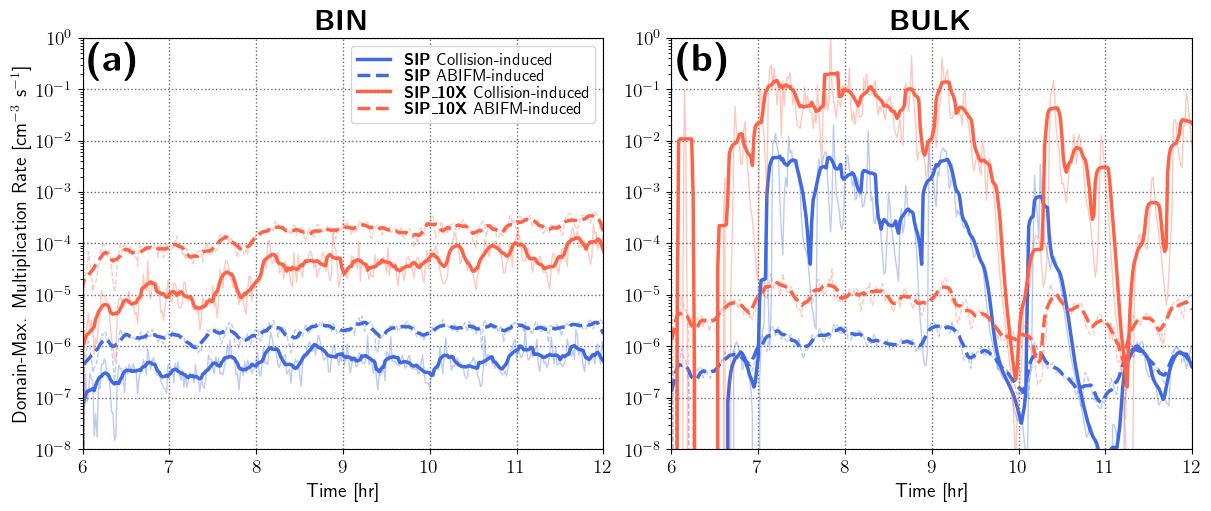

In [100]:
# ============================================================
# SIP multiplication rates — BIN vs BULK
# Left : BIN  — max_sh_coag (solid), max_sh_in (dashed)
# Right: BULK — max_sh_coag (solid), max_sh_in_r (dashed)
# SIP=royalblue, SIP_10X=tomato
# ============================================================

# --- Running mean option ---
# Set running_mean_window > 1 to overlay a smoothed line.
# Window is in number of time steps (BIN: 1/step, BULK: 2/step).
# Set to 1 (or 0) to disable.
running_mean_window = 10   # e.g. 10 steps ~ 10 min for BIN (60s cadence)

def running_mean(arr, window):
    """Simple centred running mean; edges handled with 'valid' conv + edge fill."""
    if window <= 1:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

sip_dicts_bin  = [bin_sip_d,  bin_sip10_d]
sip_dicts_bulk = [bulk_sip_d, bulk_sip10_d]
sip_names      = [r'\textbf{SIP}', r'\textbf{SIP\_10X}']
sip_colors     = ['royalblue', 'tomato']

fig_mult, (ax_bin_mult, ax_bulk_mult) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True)

# --- BIN ---
for d, color, name in zip(sip_dicts_bin, sip_colors, sip_names):
    t = d['time'] / 3600.
    coag = d['max_sh_coag']
    abif = d['max_sh_in']
    ax_bin_mult.plot(t, coag, color=color, lw=1, linestyle='solid',  alpha=0.35)
    ax_bin_mult.plot(t, abif, color=color, lw=1, linestyle='dashed', alpha=0.35)
    if running_mean_window > 1:
        ax_bin_mult.plot(t, running_mean(coag, running_mean_window),
                         color=color, lw=2.5, linestyle='solid',
                         label=name + r' Collision-induced')
        ax_bin_mult.plot(t, running_mean(abif, running_mean_window),
                         color=color, lw=2.5, linestyle='dashed',
                         label=name + r' ABIFM-induced')
    else:
        # no smoothing — thicken the raw lines and add labels
        ax_bin_mult.lines[-2].set_linewidth(2)
        ax_bin_mult.lines[-2].set_alpha(1.0)
        ax_bin_mult.lines[-2].set_label(name + r' Collision-induced')
        ax_bin_mult.lines[-1].set_linewidth(2)
        ax_bin_mult.lines[-1].set_alpha(1.0)
        ax_bin_mult.lines[-1].set_label(name + r' ABIFM-induced')

ax_bin_mult.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bin_mult.set_ylabel('Domain-Max. Multiplication Rate [cm$^{-3}$ s$^{-1}$]', fontsize=Fontsize)
ax_bin_mult.tick_params(labelsize=Fontsize)
ax_bin_mult.legend(fontsize=Fontsize * 0.85, labelspacing=0.1)
ax_bin_mult.grid(ls='dotted', lw=1, c='dimgrey')
ax_bin_mult.set_title(r'\textbf{BIN}', fontsize=Fontsize * 1.5)
ax_bin_mult.set_yscale('log')
ax_bin_mult.set_ylim(1.e-8, 1.e0)

# --- BULK ---
for d, color, name in zip(sip_dicts_bulk, sip_colors, sip_names):
    t = d['tmp_time']
    coag = d['max_sh_coag']
    abif = d['max_sh_in_r']
    ax_bulk_mult.plot(t, coag, color=color, lw=1, linestyle='solid',  alpha=0.35)
    ax_bulk_mult.plot(t, abif, color=color, lw=1, linestyle='dashed', alpha=0.35)
    if running_mean_window > 1:
        ax_bulk_mult.plot(t, running_mean(coag, running_mean_window),
                          color=color, lw=2.5, linestyle='solid',
                          label=name + r' Collision-induced')
        ax_bulk_mult.plot(t, running_mean(abif, running_mean_window),
                          color=color, lw=2.5, linestyle='dashed',
                          label=name + r' ABIFM-induced')
    else:
        ax_bulk_mult.lines[-2].set_linewidth(2)
        ax_bulk_mult.lines[-2].set_alpha(1.0)
        ax_bulk_mult.lines[-2].set_label(name + r' Collision-induced')
        ax_bulk_mult.lines[-1].set_linewidth(2)
        ax_bulk_mult.lines[-1].set_alpha(1.0)
        ax_bulk_mult.lines[-1].set_label(name + r' ABIFM-induced')

ax_bulk_mult.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bulk_mult.tick_params(labelsize=Fontsize)
ax_bulk_mult.grid(ls='dotted', lw=1, c='dimgrey')
ax_bulk_mult.set_title(r'\textbf{BULK}', fontsize=Fontsize * 1.5)
ax_bulk_mult.set_yscale('log')
ax_bulk_mult.set_ylim(1.e-8, 1.e0)

ax_bin_mult.text(0.01, 0.99, r'\textbf{(a)}', fontsize=Fontsize*2,
                 transform=ax_bin_mult.transAxes, ha='left', va='top')
ax_bulk_mult.text(0.01, 0.99, r'\textbf{(b)}', fontsize=Fontsize*2,
                  transform=ax_bulk_mult.transAxes, ha='left', va='top')


ax_bin_mult.set_xlim(6,12)
ax_bulk_mult.set_xlim(6,12)

plt.show()


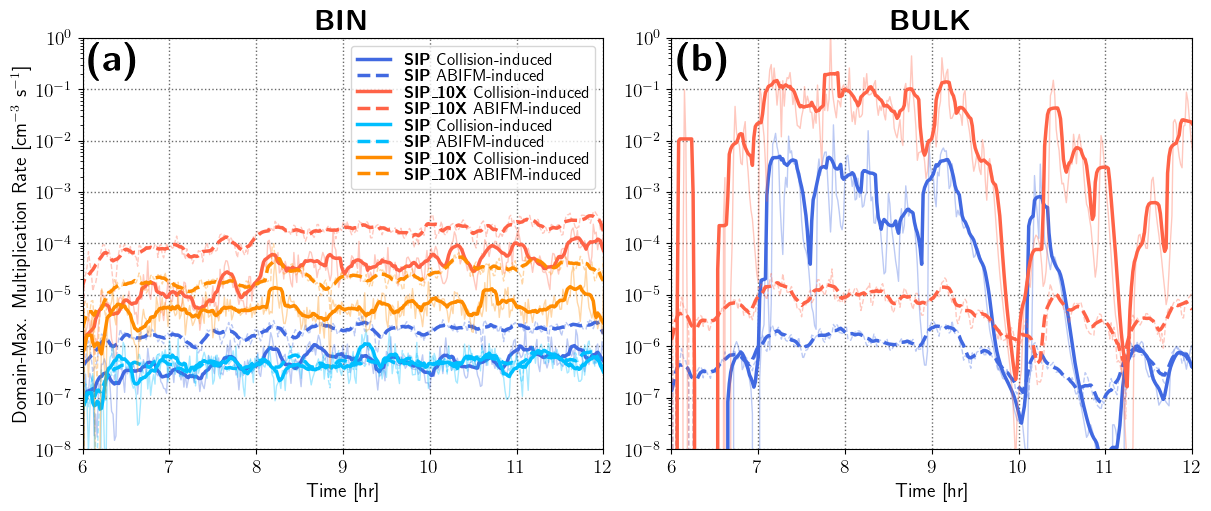

In [118]:
# ============================================================
# SIP multiplication rates — BIN vs BULK
# Left : BIN  — max_sh_coag (solid), max_sh_in (dashed)
# Right: BULK — max_sh_coag (solid), max_sh_in_r (dashed)
# SIP=royalblue, SIP_10X=tomato
# ============================================================

# --- Running mean option ---
# Set running_mean_window > 1 to overlay a smoothed line.
# Window is in number of time steps (BIN: 1/step, BULK: 2/step).
# Set to 1 (or 0) to disable.
running_mean_window = 10   # e.g. 10 steps ~ 10 min for BIN (60s cadence)

def running_mean(arr, window):
    """Simple centred running mean; edges handled with 'valid' conv + edge fill."""
    if window <= 1:
        return arr
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

sip_dicts_bin  = [bin_sip_d,  bin_sip10_d, bin_sip_noturb_d, bin_sip10_noturb_d]
sip_names      = [r'\textbf{SIP}', r'\textbf{SIP\_10X}', r'\textbf{SIP}', r'\textbf{SIP\_10X}',]
sip_colors     = ['royalblue', 'tomato','deepskyblue','darkorange']

fig_mult, (ax_bin_mult, ax_bulk_mult) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True)

# --- BIN ---
for d, color, name in zip(sip_dicts_bin, sip_colors, sip_names):
    t = d['time'] / 3600.
    coag = d['max_sh_coag']
    abif = d['max_sh_in']
    ax_bin_mult.plot(t, coag, color=color, lw=1, linestyle='solid',  alpha=0.35)
    ax_bin_mult.plot(t, abif, color=color, lw=1, linestyle='dashed', alpha=0.35)
    if running_mean_window > 1:
        ax_bin_mult.plot(t, running_mean(coag, running_mean_window),
                         color=color, lw=2.5, linestyle='solid',
                         label=name + r' Collision-induced')
        ax_bin_mult.plot(t, running_mean(abif, running_mean_window),
                         color=color, lw=2.5, linestyle='dashed',
                         label=name + r' ABIFM-induced')
    else:
        # no smoothing — thicken the raw lines and add labels
        ax_bin_mult.lines[-2].set_linewidth(2)
        ax_bin_mult.lines[-2].set_alpha(1.0)
        ax_bin_mult.lines[-2].set_label(name + r' Collision-induced')
        ax_bin_mult.lines[-1].set_linewidth(2)
        ax_bin_mult.lines[-1].set_alpha(1.0)
        ax_bin_mult.lines[-1].set_label(name + r' ABIFM-induced')

ax_bin_mult.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bin_mult.set_ylabel('Domain-Max. Multiplication Rate [cm$^{-3}$ s$^{-1}$]', fontsize=Fontsize)
ax_bin_mult.tick_params(labelsize=Fontsize)
ax_bin_mult.legend(fontsize=Fontsize * 0.85, labelspacing=0.1)
ax_bin_mult.grid(ls='dotted', lw=1, c='dimgrey')
ax_bin_mult.set_title(r'\textbf{BIN}', fontsize=Fontsize * 1.5)
ax_bin_mult.set_yscale('log')
ax_bin_mult.set_ylim(1.e-8, 1.e0)

sip_dicts_bulk = [bulk_sip_d, bulk_sip10_d]
sip_names      = [r'\textbf{SIP}', r'\textbf{SIP\_10X}']
sip_colors     = ['royalblue', 'tomato']

# --- BULK ---
for d, color, name in zip(sip_dicts_bulk, sip_colors, sip_names):
    t = d['tmp_time']
    coag = d['max_sh_coag']
    abif = d['max_sh_in_r']
    ax_bulk_mult.plot(t, coag, color=color, lw=1, linestyle='solid',  alpha=0.35)
    ax_bulk_mult.plot(t, abif, color=color, lw=1, linestyle='dashed', alpha=0.35)
    if running_mean_window > 1:
        ax_bulk_mult.plot(t, running_mean(coag, running_mean_window),
                          color=color, lw=2.5, linestyle='solid',
                          label=name + r' Collision-induced')
        ax_bulk_mult.plot(t, running_mean(abif, running_mean_window),
                          color=color, lw=2.5, linestyle='dashed',
                          label=name + r' ABIFM-induced')
    else:
        ax_bulk_mult.lines[-2].set_linewidth(2)
        ax_bulk_mult.lines[-2].set_alpha(1.0)
        ax_bulk_mult.lines[-2].set_label(name + r' Collision-induced')
        ax_bulk_mult.lines[-1].set_linewidth(2)
        ax_bulk_mult.lines[-1].set_alpha(1.0)
        ax_bulk_mult.lines[-1].set_label(name + r' ABIFM-induced')

ax_bulk_mult.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bulk_mult.tick_params(labelsize=Fontsize)
ax_bulk_mult.grid(ls='dotted', lw=1, c='dimgrey')
ax_bulk_mult.set_title(r'\textbf{BULK}', fontsize=Fontsize * 1.5)
ax_bulk_mult.set_yscale('log')
ax_bulk_mult.set_ylim(1.e-8, 1.e0)

ax_bin_mult.text(0.01, 0.99, r'\textbf{(a)}', fontsize=Fontsize*2,
                 transform=ax_bin_mult.transAxes, ha='left', va='top')
ax_bulk_mult.text(0.01, 0.99, r'\textbf{(b)}', fontsize=Fontsize*2,
                  transform=ax_bulk_mult.transAxes, ha='left', va='top')


ax_bin_mult.set_xlim(6,12)
ax_bulk_mult.set_xlim(6,12)

plt.show()


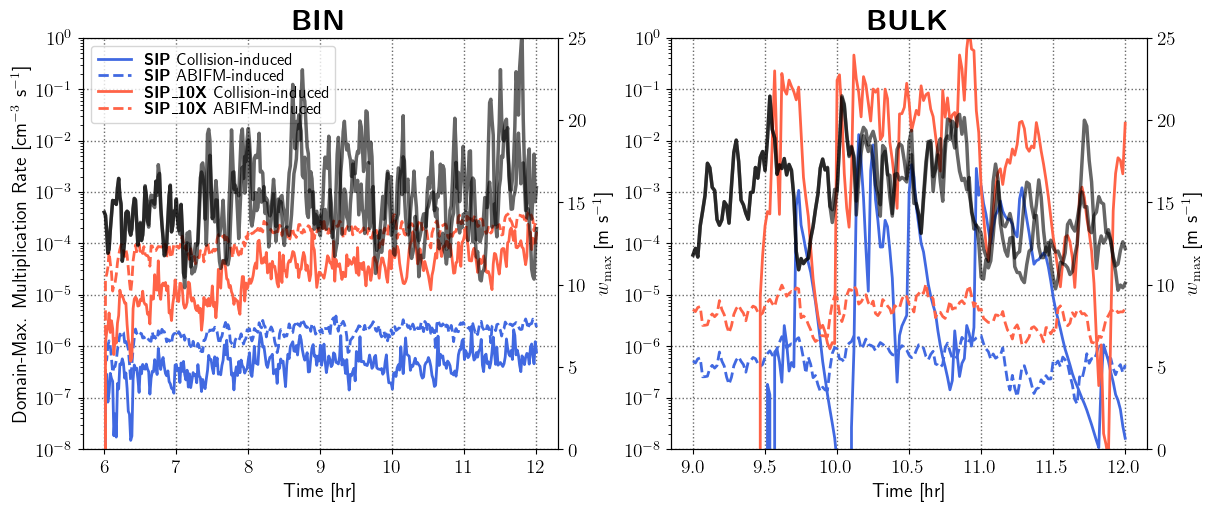

In [124]:
# ============================================================
# SIP multiplication rates + max_w twin axis — BIN vs BULK
# Left : BIN  — max_sh_coag (solid), max_sh_in (dashed)
# Right: BULK — max_sh_coag (solid), max_sh_in_r (dashed)
# Twin y-axis: domain-max w [m/s], black line, all sims
# SIP=royalblue, SIP_10X=tomato
# ============================================================
w_color = 'k'

fig_mult2, (ax_bin_m2, ax_bulk_m2) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True)

# --- BIN ---
for d, color, name in zip(sip_dicts_bin, sip_colors, sip_names):
    t = d['time'] / 3600.
    ax_bin_m2.plot(t, d['max_sh_coag'], color=color, lw=2, linestyle='solid',
                   label=name + r' Collision-induced')
    ax_bin_m2.plot(t, d['max_sh_in'],   color=color, lw=2, linestyle='dashed',
                   label=name + r' ABIFM-induced')

ax_bin_m2.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bin_m2.set_ylabel('Domain-Max. Multiplication Rate [cm$^{-3}$ s$^{-1}$]', fontsize=Fontsize)
ax_bin_m2.tick_params(labelsize=Fontsize)
ax_bin_m2.legend(fontsize=Fontsize * 0.85, labelspacing=0.1, loc='upper left')
ax_bin_m2.grid(ls='dotted', lw=1, c='dimgrey')
ax_bin_m2.set_title(r'\textbf{BIN}', fontsize=Fontsize * 1.5)
ax_bin_m2.set_yscale('log')
ax_bin_m2.set_ylim(1.e-8, 1.e0)

ax_bin_w = ax_bin_m2.twinx()
for d, color, name in zip(sip_dicts_bin, sip_colors, sip_names):
    t = d['time'] / 3600.
    ax_bin_w.plot(t, d['max_w'], color=w_color, lw=2.5, linestyle='solid', alpha=0.6)
ax_bin_w.set_ylabel(r'$w_{\mathrm{max}}$ [m s$^{-1}$]', fontsize=Fontsize, color=w_color)
ax_bin_w.tick_params(labelsize=Fontsize, labelcolor=w_color)
ax_bin_w.spines['right'].set_color(w_color)
ax_bin_w.set_ylim(0,25)

# --- BULK ---
for d, color, name in zip(sip_dicts_bulk, sip_colors, sip_names):
    t = d['tmp_time']
    ax_bulk_m2.plot(t, d['max_sh_coag'], color=color, lw=2, linestyle='solid',
                    label=name + r' Collision-induced')
    ax_bulk_m2.plot(t, d['max_sh_in_r'], color=color, lw=2, linestyle='dashed',
                    label=name + r' ABIFM-induced')

ax_bulk_m2.set_xlabel('Time [hr]', fontsize=Fontsize)
ax_bulk_m2.tick_params(labelsize=Fontsize)
ax_bulk_m2.grid(ls='dotted', lw=1, c='dimgrey')
ax_bulk_m2.set_title(r'\textbf{BULK}', fontsize=Fontsize * 1.5)
ax_bulk_m2.set_yscale('log')
ax_bulk_m2.set_ylim(1.e-8, 1.e0)

ax_bulk_w = ax_bulk_m2.twinx()
for d, color, name in zip(sip_dicts_bulk, sip_colors, sip_names):
    t = d['tmp_time']
    ax_bulk_w.plot(t, d['max_w'], color=w_color, lw=2.5, linestyle='solid', alpha=0.6)
ax_bulk_w.set_ylabel(r'$w_{\mathrm{max}}$ [m s$^{-1}$]', fontsize=Fontsize, color=w_color)
ax_bulk_w.tick_params(labelsize=Fontsize, labelcolor=w_color)
ax_bulk_w.spines['right'].set_color(w_color)
ax_bulk_w.set_ylim(0,25)

plt.show()


(2, 5)